1. Khai báo thư viện ảnh

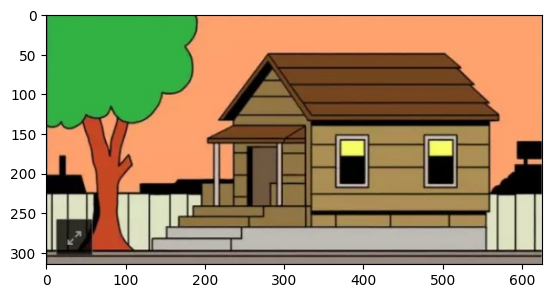

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('example.jpg')
plt.imshow(img[:,:,::-1])

2. Sử dụng Harris Corner Detection tìm các keypoint trong ảnh.

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

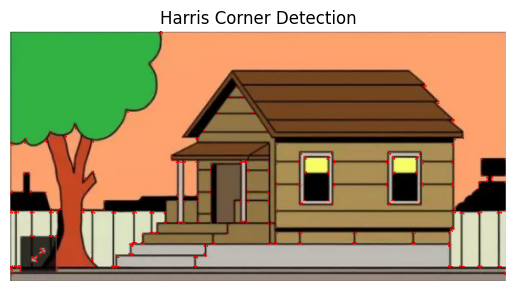

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

# Harris Corner
dst = cv2.cornerHarris(gray, 2, 3, 0.04)

# làm nổi góc
img_harris = img.copy()
img_harris[dst > 0.01 * dst.max()] = [0,0,255]

plt.imshow(img_harris[:,:,::-1])
plt.title("Harris Corner Detection")
plt.axis('off')

3. Sử dụng Band-pass filtering by Difference of Gaussians

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

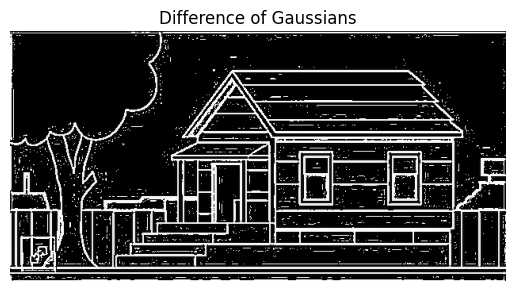

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur1 = cv2.GaussianBlur(gray,(5,5),1)
blur2 = cv2.GaussianBlur(gray,(5,5),2)

dog = blur1 - blur2

plt.imshow(dog, cmap='gray')
plt.title("Difference of Gaussians")
plt.axis('off')

4. Kiểm tra ảnh qua Automatic Scale Selection

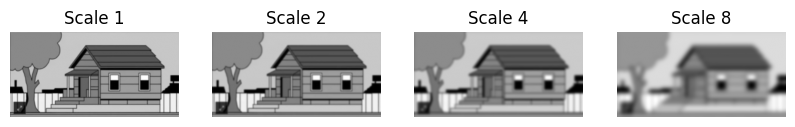

In [ ]:
scales = [1,2,4,8]

plt.figure(figsize=(10,5))

for i,s in enumerate(scales):
    blur = cv2.GaussianBlur(gray,(0,0),s)

    plt.subplot(1,len(scales),i+1)
    plt.imshow(blur,cmap='gray')
    plt.title(f"Scale {s}")
    plt.axis('off')

plt.show()

5. Kiểm tra ảnh qua Scale Invariant Detection

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

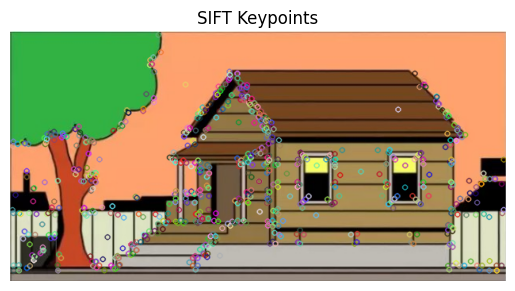

In [ ]:
sift = cv2.SIFT_create()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

keypoints, descriptors = sift.detectAndCompute(gray,None)

img_sift = cv2.drawKeypoints(img,keypoints,None)

plt.imshow(img_sift[:,:,::-1])
plt.title("SIFT Keypoints")
plt.axis('off')

6. Kiểm tra ảnh qua Scale-space blob detector.

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

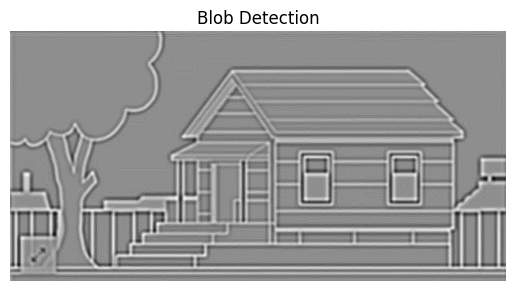

In [ ]:
blob = cv2.GaussianBlur(gray,(9,9),2)

laplacian = cv2.Laplacian(blob,cv2.CV_64F)

plt.imshow(laplacian,cmap='gray')
plt.title("Blob Detection")
plt.axis('off')

7. Thực hành với Bag-of-words detection

In [ ]:
sift = cv2.SIFT_create()

kp, des = sift.detectAndCompute(gray,None)

print("Number of keypoints:", len(kp))
print("Descriptor shape:", des.shape)

Number of keypoints: 766
Descriptor shape: (766, 128)


8. Ghép ảnh Image Panoramas

In [ ]:
img1 = cv2.imread('example.jpg')
img2 = cv2.imread('example.jpg')

stitcher = cv2.Stitcher_create()

status, pano = stitcher.stitch([img1,img2])

if status == cv2.STITCHER_OK:
    plt.imshow(pano[:,:,::-1])
    plt.title("Panorama")
    plt.axis('off')

9. Ghép ảnh Automatic mosaicing

(np.float64(-0.5), np.float64(1251.5), np.float64(314.5), np.float64(-0.5))

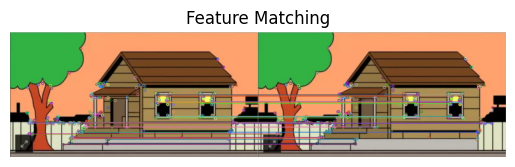

In [ ]:
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img1,None)
kp2, des2 = orb.detectAndCompute(img2,None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1,des2)

matches = sorted(matches, key=lambda x:x.distance)

match_img = cv2.drawMatches(img1,kp1,img2,kp2,matches[:50],None)

plt.imshow(match_img[:,:,::-1])
plt.title("Feature Matching")
plt.axis('off')

10. Sử dụng Wide base-line stereo

(np.float64(-0.5), np.float64(625.5), np.float64(314.5), np.float64(-0.5))

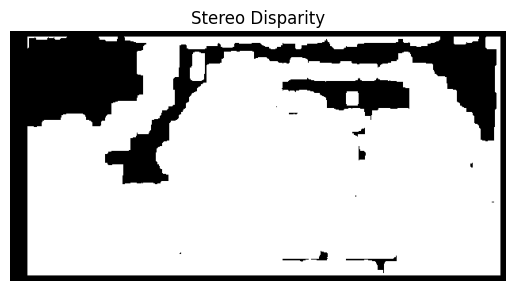

In [ ]:
stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

disparity = stereo.compute(gray1,gray2)

plt.imshow(disparity,cmap='gray')
plt.title("Stereo Disparity")
plt.axis('off')

11. CBIR (content-based image retrieval)

In [ ]:
hist = cv2.calcHist([img],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])

hist = cv2.normalize(hist,hist).flatten()

print(hist.shape)

(512,)


12. Bag-of-word with SIFT + Histogram

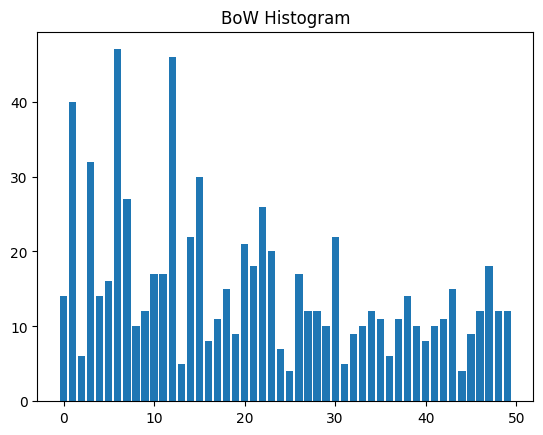

In [ ]:
from sklearn.cluster import KMeans

sift = cv2.SIFT_create()
kp, des = sift.detectAndCompute(gray,None)

k = 50

kmeans = KMeans(n_clusters=k)
kmeans.fit(des)

labels = kmeans.predict(des)

histogram = np.bincount(labels, minlength=k)

plt.bar(range(k), histogram)
plt.title("BoW Histogram")
plt.show()